In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
def load_dataset():
 #Load the dataset.
 df = pd.read_csv("../BostonHousing.csv")
 return df

Model Evaluation Metrics
Test MSE: 17.19
Test RMSE: 4.15 (Interpret as average prediction error in $1000s)
Test MAE: 2.92 (Robust to outliers)
Test R²: 0.766 (Variance explained)

=== Training Metrics ===
Train RMSE: 5.48
Train R²: 0.654
RMSE Difference: 1.34 (Smaller is better)


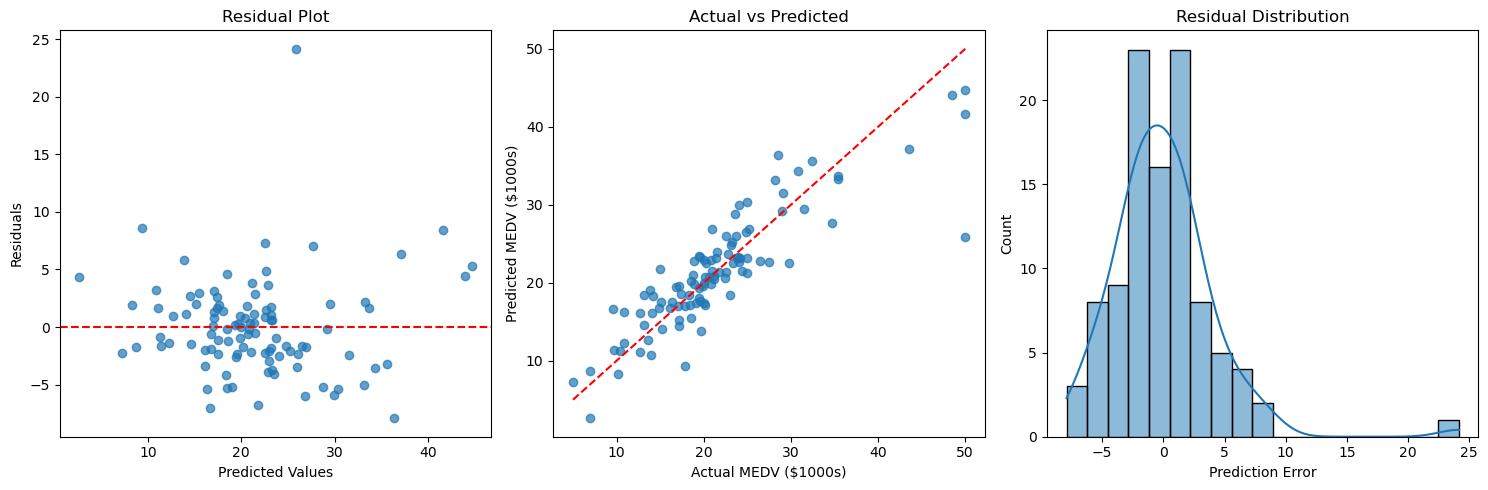

<Figure size 600x600 with 0 Axes>

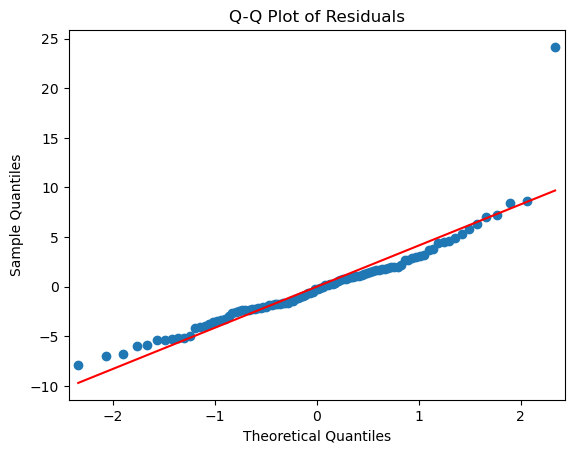

In [19]:
def evaluate_model(model, X_test_scaled, y_test, X_train_scaled, y_train):
    model = LinearRegression()
    model.fit(X_test_scaled, y_test)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    if X_train_scaled is not None and y_train is not None:
        train_pred = model.predict(X_train_scaled)
        train_mse = mean_squared_error(y_train, train_pred)
        train_rmse = np.sqrt(train_mse)
        train_r2 = r2_score(y_train, train_pred)

    print("Model Evaluation Metrics")
    print(f"Test MSE: {mse:.2f}")
    print(f"Test RMSE: {rmse:.2f} (Interpret as average prediction error in $1000s)")
    print(f"Test MAE: {mae:.2f} (Robust to outliers)")
    print(f"Test R²: {r2:.3f} (Variance explained)")
    
    if 'train_rmse' in locals():
        print("\n=== Training Metrics ===")
        print(f"Train RMSE: {train_rmse:.2f}")
        print(f"Train R²: {train_r2:.3f}")
        print(f"RMSE Difference: {abs(train_rmse - rmse):.2f} (Smaller is better)")

        residuals = y_test - y_pred
    
    plt.figure(figsize=(15, 5))
    
    # Residual Plot
    plt.subplot(1, 3, 1)
    plt.scatter(y_pred, residuals, alpha=0.7)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residual Plot')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    
    # Prediction Accuracy
    plt.subplot(1, 3, 2)
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 'r--')
    plt.title('Actual vs Predicted')
    plt.xlabel('Actual MEDV ($1000s)')
    plt.ylabel('Predicted MEDV ($1000s)')
    
    # Error Distribution
    plt.subplot(1, 3, 3)
    sns.histplot(residuals, kde=True)
    plt.title('Residual Distribution')
    plt.xlabel('Prediction Error')
    
    plt.tight_layout()
    plt.show()

    # Q-Q Plot for normality check
    from statsmodels.graphics.gofplots import qqplot
    plt.figure(figsize=(6, 6))
    qqplot(residuals, line='s')
    plt.title('Q-Q Plot of Residuals')
    plt.show()

    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'residuals': residuals
    }
def evaluate():
    df = load_dataset()
    X = df.drop('medv', axis = 1)
    y = df['medv']
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state=42)
    

    evaluate_model(df, X_test, y_test, X_train, y_train)
evaluate()

In [8]:
from statsmodels.graphics.gofplots import qqplot
from sklearn.preprocessing import StandardScaler

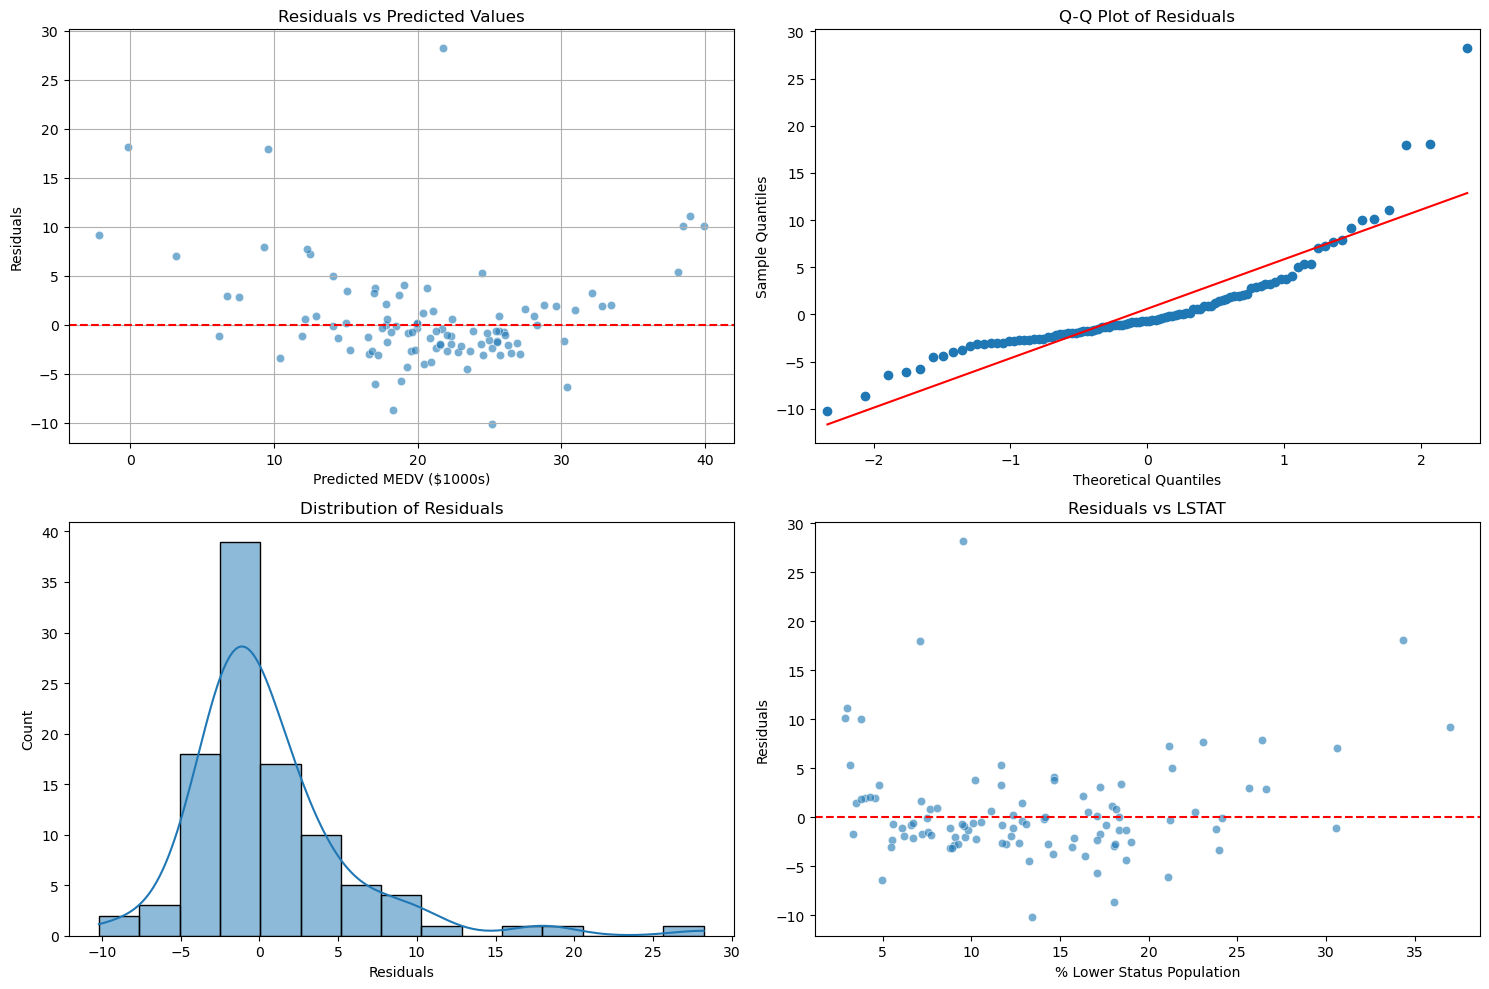

In [9]:
def residual_plot():
    df = load_dataset()
    X = df[['lstat', 'rm', 'ptratio', 'indus', 'tax']]  # Selected features
    y = df['medv']  

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    residuals = y_test - y_pred

    plt.figure(figsize=(15, 10))

    # 1. Residuals vs Predicted Values
    plt.subplot(2, 2, 1)
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residuals vs Predicted Values')
    plt.xlabel('Predicted MEDV ($1000s)')
    plt.ylabel('Residuals')
    plt.grid(True)

    # 2. Q-Q Plot for Normality
    plt.subplot(2, 2, 2)
    qqplot(residuals, line='s', ax=plt.gca())
    plt.title('Q-Q Plot of Residuals')

    # 3. Residual Distribution
    plt.subplot(2, 2, 3)
    sns.histplot(residuals, kde=True, bins=15)
    plt.title('Distribution of Residuals')
    plt.xlabel('Residuals')

    # 4. Residuals vs Features (using LSTAT as example)
    plt.subplot(2, 2, 4)
    sns.scatterplot(x=X_test['lstat'], y=residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residuals vs LSTAT')
    plt.xlabel('% Lower Status Population')
    plt.ylabel('Residuals')

    plt.tight_layout()
    plt.show()

residual_plot()

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

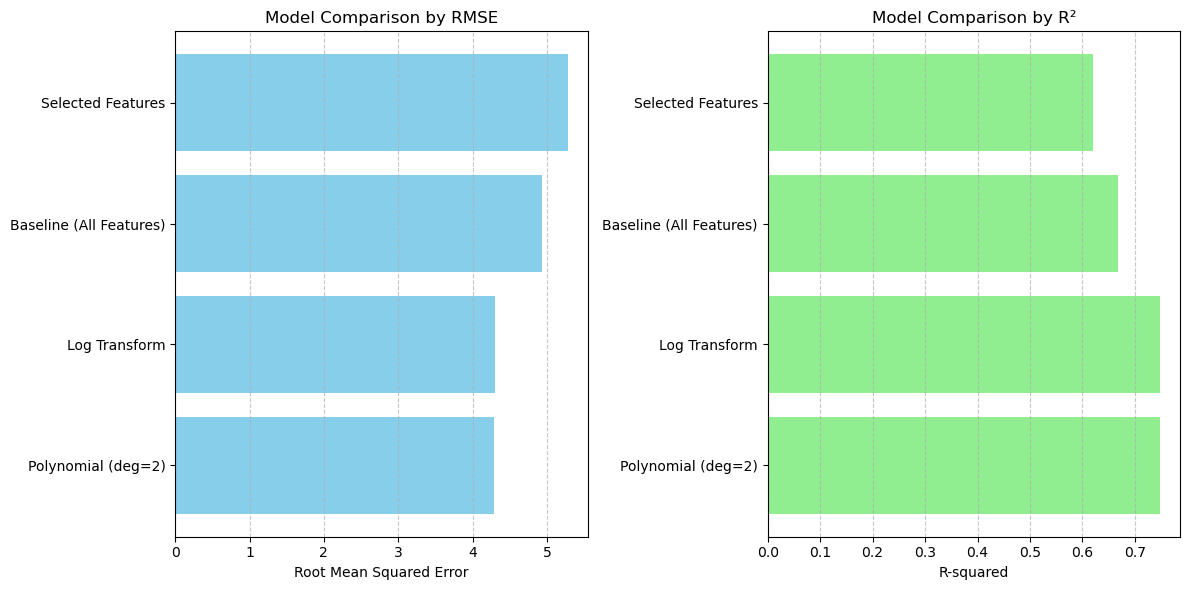


=== Model Performance Comparison ===


,Case,Features,Preprocessing,RMSE,R²
2,Polynomial (deg=2),"lstat, rm",poly,4.29,0.749
3,Log Transform,"crim, zn, indus...",log,4.30,0.748
0,Baseline (All Features),"crim, zn, indus...",none,4.93,0.669
1,Selected Features,"lstat, rm, ptratio...",standardize,5.28,0.620


In [12]:
def Comparision():
    df = load_dataset()

    X = df.drop('medv', axis=1)
    y = df['medv']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    cases = {
        'Baseline (All Features)': {
            'features': X.columns.tolist(),
            'preprocess': None
        },
        'Selected Features': {
            'features': ['lstat', 'rm', 'ptratio', 'indus', 'tax'],
            'preprocess': 'standardize'
        },
        'Polynomial (deg=2)': {
            'features': ['lstat', 'rm'],
            'preprocess': 'poly'
        },
        'Log Transform': {
            'features': X.columns.tolist(),
            'preprocess': 'log'
        }
    }

    # Evaluation function
    def evaluate_case(X_train, X_test, y_train, y_test, preprocess):
        if preprocess == 'standardize':
            scaler = StandardScaler()
            X_train_processed = scaler.fit_transform(X_train)
            X_test_processed = scaler.transform(X_test)
        elif preprocess == 'poly':
            poly = PolynomialFeatures(degree=2, include_bias=False)
            X_train_processed = poly.fit_transform(X_train)
            X_test_processed = poly.transform(X_test)
        elif preprocess == 'log':
            X_train_processed = np.log(X_train + 1)  # +1 to avoid log(0)
            X_test_processed = np.log(X_test + 1)
        else:
            X_train_processed = X_train.values
            X_test_processed = X_test.values

        model = LinearRegression()
        model.fit(X_train_processed, y_train)

        y_pred = model.predict(X_test_processed)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        return rmse, r2

    # Compare all cases
    results = []
    for case_name, config in cases.items():
        X_train_sub = X_train[config['features']]
        X_test_sub = X_test[config['features']]

        rmse, r2 = evaluate_case(X_train_sub, X_test_sub, y_train, y_test, config['preprocess'])
        results.append({
            'Case': case_name,
            'Features': ', '.join(config['features'][:3]) + ('...' if len(config['features']) > 3 else ''),
            'Preprocessing': config['preprocess'] or 'none',
            'RMSE': rmse,
            'R²': r2
        })

    # Create results dataframe
    results_df = pd.DataFrame(results).sort_values('RMSE')

    # Visualization
    plt.figure(figsize=(12, 6))

    # RMSE Comparison
    plt.subplot(1, 2, 1)
    plt.barh(results_df['Case'], results_df['RMSE'], color='skyblue')
    plt.title('Model Comparison by RMSE')
    plt.xlabel('Root Mean Squared Error')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # R² Comparison
    plt.subplot(1, 2, 2)
    plt.barh(results_df['Case'], results_df['R²'], color='lightgreen')
    plt.title('Model Comparison by R²')
    plt.xlabel('R-squared')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Display results table
    print("\n=== Model Performance Comparison ===")
    print(results_df.style
           .background_gradient(subset=['RMSE'], cmap='Blues_r')
           .background_gradient(subset=['R²'], cmap='Greens')
           .format({'RMSE': '{:.2f}', 'R²': '{:.3f}'}))

Comparision()